In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from shapely.geometry import box as shapely_box
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.ticker import FuncFormatter

In [2]:
# =============================================================================
# PART 1: Identification, Statistics, & Filtering of Lakes
# =============================================================================

# 1. Load the dataset
df = pd.read_csv("../alaska_lakes_ice_phenology_2019-2023.csv")

# Standardize string checking
df["ice_off_status"] = df["ice_off_status"].astype(str).str.strip().str.lower()
df["ice_on_status"] = df["ice_on_status"].astype(str).str.strip().str.lower()

# --- Global Phenology DOY Ranges & 2-Sigma Outliers ---
print("--- Global Phenology DOY Stats & Outlier Analysis ---")
total_lake_dates = len(df)

for col_name, label in [("ice_off_doy", "Ice-Off"), ("ice_on_doy", "Ice-On")]:
    valid_data = df[col_name].dropna()
    total_valid = len(valid_data)
    
    # Raw bounds
    raw_min, raw_max = valid_data.min(), valid_data.max()
    
    # Calculate 2 standard deviation thresholds
    mean_val = valid_data.mean()
    sd_val = valid_data.std()
    lower_2sd = mean_val - (2 * sd_val)
    upper_2sd = mean_val + (2 * sd_val)
    
    # Identify records outside 2-sigma thresholds
    outliers = valid_data[(valid_data < lower_2sd) | (valid_data > upper_2sd)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / total_valid) * 100 if total_valid > 0 else 0
    
    print(f"{label} Metrics:")
    print(f"  * Raw Range: {raw_min:.0f} to {raw_max:.0f} DOY")
    print(f"  * Mean ± 2 SD Window: {lower_2sd:.1f} to {upper_2sd:.1f} DOY (Mean: {mean_val:.1f}, SD: {sd_val:.1f})")
    print(f"  * Outliers outside ± 2 SD: {outlier_count:,} lake-dates ({outlier_pct:.2f}% of valid records)\n")


# --- NEW: Correlation Test between Ice-Off and Ice-On ---
# Drop rows missing either ice_off_doy or ice_on_doy to ensure valid pairs
paired_data = df.dropna(subset=["ice_off_doy", "ice_on_doy"])

if len(paired_data) > 1:
    r_val, p_val = pearsonr(paired_data["ice_off_doy"], paired_data["ice_on_doy"])
    print("--- Phenology Correlation Analysis ---")
    print(f"Number of complete paired lake-dates: {len(paired_data):,}")
    print(f"Pearson correlation coefficient (r): {r_val:.3f}")
    print(f"P-value: {p_val:.3e}\n")
else:
    print("--- Phenology Correlation Analysis ---")
    print("Not enough complete pairs to calculate correlation.\n")


# --- Calculate Annual Phenology Means ---
print("--- Annual Phenology Means ---")
annual_means = df.groupby("year")[["ice_off_doy", "ice_on_doy", "ice_free_days"]].mean()
for yr, row in annual_means.iterrows():
    print(f"Year {yr} -> Mean Ice-Off: {row['ice_off_doy']:.1f} | Mean Ice-On: {row['ice_on_doy']:.1f} | Mean Ice-Free Days: {row['ice_free_days']:.1f}")
print("")


# --- Calculate 5-Year Full Phenology Completeness Percentage ---
df["years_recorded"] = df.groupby("lake_id")["year"].transform("count")
df["is_exact"] = (df["ice_off_status"] == "exact") & (df["ice_on_status"] == "exact")
full_pheno_mask = df.groupby("lake_id")["is_exact"].transform("all")

lakes_with_5_years = df[df["years_recorded"] == 5]
total_5yr_lakes_count = lakes_with_5_years["lake_id"].nunique()

perfect_5yr_lakes = lakes_with_5_years[full_pheno_mask]
perfect_5yr_count = perfect_5yr_lakes["lake_id"].nunique()

pct_full_pheno_5yr = (perfect_5yr_count / total_5yr_lakes_count) * 100 if total_5yr_lakes_count > 0 else 0

print("--- Data Completeness Tracking ---")
print(f"Unique lakes with a full 5-year record sequence: {total_5yr_lakes_count:,}")
print(f"Lakes with full phenology ('exact') across all 5 years: {perfect_5yr_count:,}")
print(f"Percentage of 5-year lakes with perfect phenology: {pct_full_pheno_5yr:.2f}%\n")


# --- No Phenology Detected Subset ---
df["is_none"] = (df["ice_off_status"] == "none") & (df["ice_on_status"] == "none")
no_phenology_mask = df.groupby("lake_id")["is_none"].transform("all")
no_pheno_df = df[no_phenology_mask]

columns_to_extract = ["lake_id", "centroid_lat", "centroid_lon", "area_km2", "sdi", "convexity"]
total_unique_table = df[columns_to_extract].drop_duplicates(subset=["lake_id"]).copy()
no_pheno_table = no_pheno_df[columns_to_extract].drop_duplicates(subset=["lake_id"]).copy()

total_count = len(total_unique_table)
no_pheno_count = len(no_pheno_table)
print(f"Total Population of Unique Lakes (Baseline): {total_count:,}")
print(f"Unique Lakes with No Phenology Detected: {no_pheno_count:,}")
print(f"Percentage of Total Base Population: {(no_pheno_count / total_count) * 100:.2f}%\n")

--- Global Phenology DOY Stats & Outlier Analysis ---
Ice-Off Metrics:
  * Raw Range: 2 to 350 DOY
  * Mean ± 2 SD Window: 132.6 to 185.1 DOY (Mean: 158.9, SD: 13.1)
  * Outliers outside ± 2 SD: 6,325 lake-dates (4.17% of valid records)

Ice-On Metrics:
  * Raw Range: 3 to 366 DOY
  * Mean ± 2 SD Window: 237.0 to 308.4 DOY (Mean: 272.7, SD: 17.9)
  * Outliers outside ± 2 SD: 8,641 lake-dates (5.72% of valid records)

--- Phenology Correlation Analysis ---
Number of complete paired lake-dates: 150,942
Pearson correlation coefficient (r): -0.488
P-value: 0.000e+00

--- Annual Phenology Means ---
Year 2019 -> Mean Ice-Off: 157.0 | Mean Ice-On: 278.7 | Mean Ice-Free Days: 122.0
Year 2020 -> Mean Ice-Off: 158.2 | Mean Ice-On: 274.0 | Mean Ice-Free Days: 116.0
Year 2021 -> Mean Ice-Off: 158.0 | Mean Ice-On: 266.1 | Mean Ice-Free Days: 108.1
Year 2022 -> Mean Ice-Off: 164.2 | Mean Ice-On: 269.7 | Mean Ice-Free Days: 105.6
Year 2023 -> Mean Ice-Off: 157.1 | Mean Ice-On: 274.8 | Mean Ice-Free D

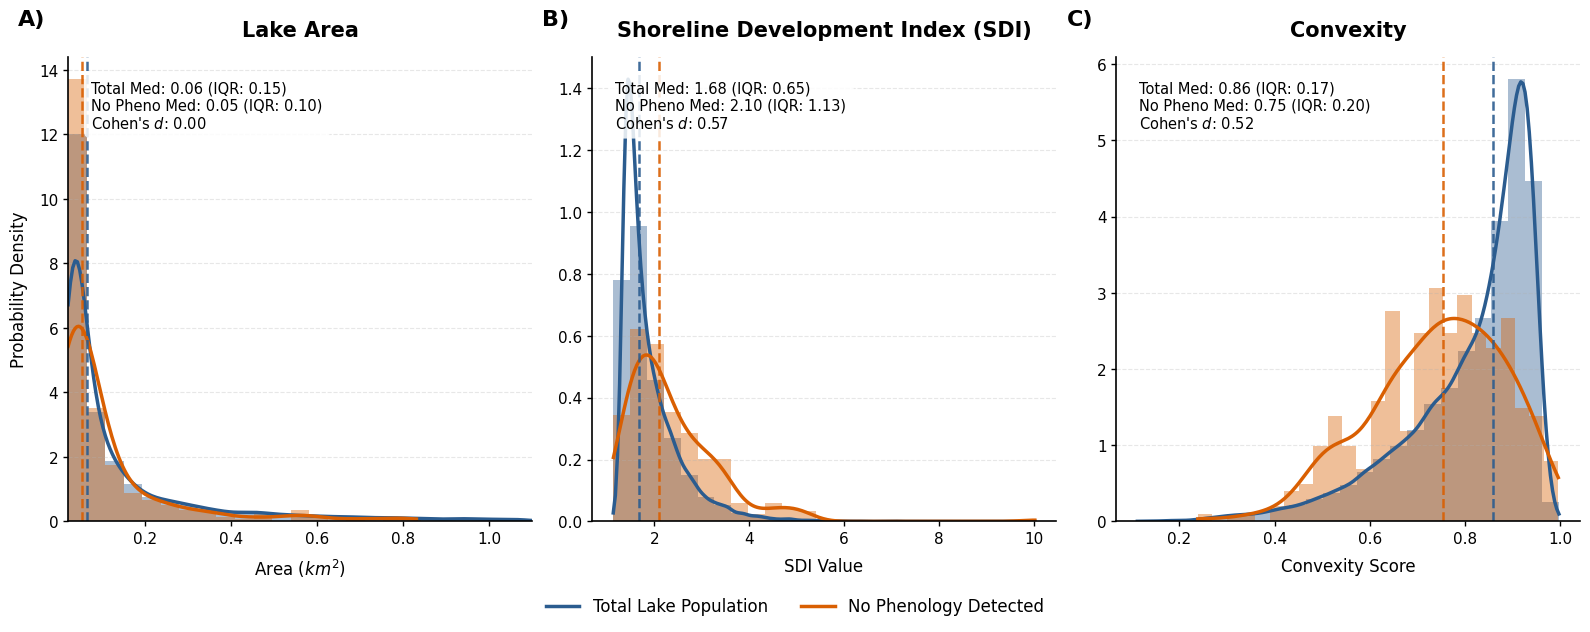

In [3]:
# =============================================================================
# PART 2: 3-Panel Distribution & Separability Histograms
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0

metrics = ["area_km2", "sdi", "convexity"]
titles = ["Lake Area", "Shoreline Development Index (SDI)", "Convexity"]
x_labels = ["Area ($km^2$)", "SDI Value", "Convexity Score"]
panel_labels = ["A)", "B)", "C)"]  

colors = {"total": "#2b5c8f", "no_pheno": "#d95f02"} 
bins_count = 25

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False) 

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Isolate arrays and drop NaNs
    t_data = total_unique_table[metric].dropna().values
    n_data = no_pheno_table[metric].dropna().values
    
    # Define range for binning (Apply 95th percentile limit ONLY to lake area)
    if metric == "area_km2":
        min_val = t_data.min()
        max_val = np.percentile(t_data, 95)
        plot_range = (min_val, max_val)
        
        # Clip data arrays for the KDE step to avoid plotting outside bounds
        t_data_clipped = t_data[t_data <= max_val]
        n_data_clipped = n_data[n_data <= max_val]
    else:
        plot_range = None
        t_data_clipped = t_data
        n_data_clipped = n_data
    
    # 1. Plot normalized histograms
    ax.hist(t_data, bins=bins_count, range=plot_range, density=True, alpha=0.4, color=colors["total"], edgecolor="none")
    ax.hist(n_data, bins=bins_count, range=plot_range, density=True, alpha=0.4, color=colors["no_pheno"], edgecolor="none")
    
    # 2. Smooth KDE Lines (evaluated within the respective plot limits)
    if len(t_data_clipped) > 1:
        kde_t = gaussian_kde(t_data_clipped)
        x_eval = np.linspace(t_data_clipped.min(), t_data_clipped.max(), 200)
        ax.plot(x_eval, kde_t(x_eval), color=colors["total"], lw=2.5)
        
    if len(n_data_clipped) > 1:
        kde_n = gaussian_kde(n_data_clipped)
        x_eval = np.linspace(n_data_clipped.min(), n_data_clipped.max(), 200)
        ax.plot(x_eval, kde_n(x_eval), color=colors["no_pheno"], lw=2.5)

    # 3. Add Vertical Median Lines (computed from full unclipped data for accuracy)
    med_t = np.median(t_data)
    med_n = np.median(n_data)
    ax.axvline(med_t, color=colors["total"], linestyle="--", lw=1.8, alpha=0.9)
    ax.axvline(med_n, color=colors["no_pheno"], linestyle="--", lw=1.8, alpha=0.9)
    
    # 4. Calculate Cohen's d Effect Size (based on full unclipped data)
    pool_sd = np.sqrt((np.var(t_data, ddof=1) + np.var(n_data, ddof=1)) / 2)
    cohens_d = abs(np.mean(t_data) - np.mean(n_data)) / pool_sd if pool_sd > 0 else 0
    
    # Calculate IQRs
    iqr_t = np.percentile(t_data, 75) - np.percentile(t_data, 25)
    iqr_n = np.percentile(n_data, 75) - np.percentile(n_data, 25)
    
    stats_text = (
        f"Total Med: {med_t:.2f} (IQR: {iqr_t:.2f})\n"
        f"No Pheno Med: {med_n:.2f} (IQR: {iqr_n:.2f})\n"
        f"Cohen's $d$: {cohens_d:.2f}"
    )
    
    # 5. Display Stats Box
    ax.text(
        0.05, 0.95, stats_text, 
        transform=ax.transAxes, 
        fontsize=10.5, 
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="none", alpha=0.85)
    )
    
    # If it's the area panel, explicitly enforce the x-limit clip boundary
    if metric == "area_km2":
        ax.set_xlim(min_val, max_val)
        
    # Formatting
    ax.set_title(titles[i], fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(x_labels[i], fontsize=12, labelpad=8)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=11)
    
    ax.text(-0.05, 1.06, panel_labels[i], transform=ax.transAxes, fontsize=16, fontweight="bold", va="bottom", ha="right")

axes[0].set_ylabel("Probability Density", fontsize=12, labelpad=8)

# Legend matching requested style
labels = ["Total Lake Population", "No Phenology Detected"]
handles = [
    plt.Line2D([0], [0], color=colors["total"], lw=2.5, linestyle="-"),
    plt.Line2D([0], [0], color=colors["no_pheno"], lw=2.5, linestyle="-")
]
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("lake_phenology_population_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Fetching official Alaska basemap and processing spatial data...


Building spatial indexes and running spatial joins...


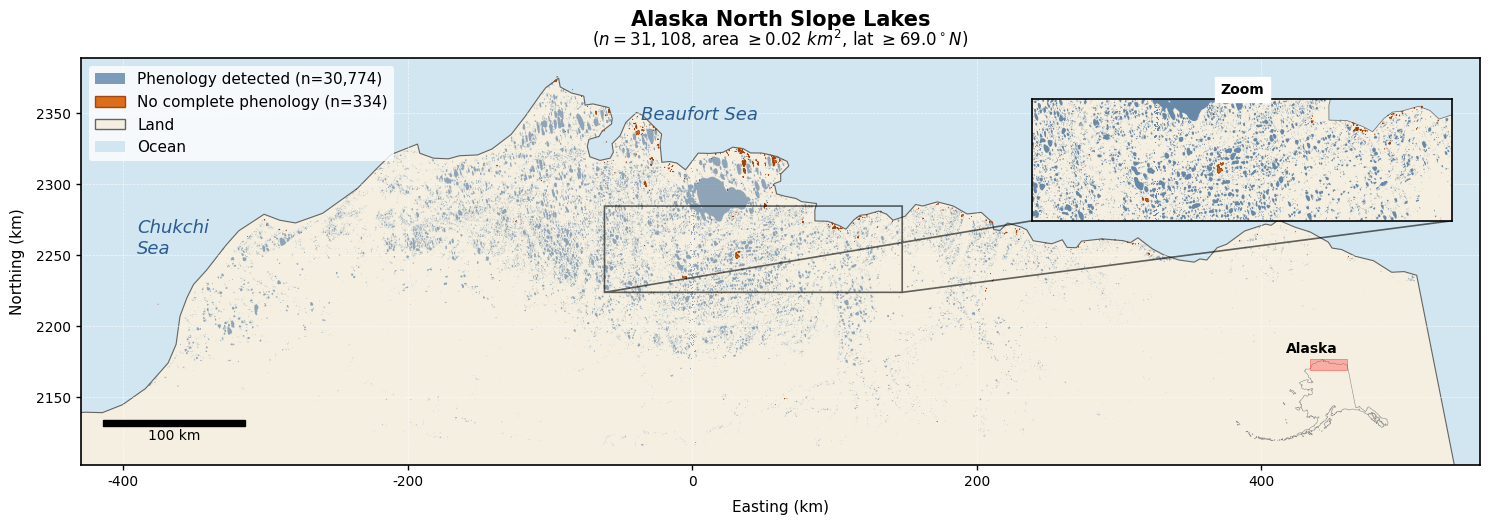

In [4]:
# =============================================================================
# PART 3: Spatial Join & Geographic Map Generation
# =============================================================================
print("Fetching official Alaska basemap and processing spatial data...")

us_states_url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
us_states = gpd.read_file(us_states_url)
alaska_landmass = us_states[us_states["NAME"] == "Alaska"]

alpod_gdf = gpd.read_file("gs://wustl-eeps-geospatial/thermokarst_lakes/ALPODlakes/ALPODlakes.shp")

total_points_gpd = gpd.GeoDataFrame(
    total_unique_table,
    geometry=gpd.points_from_xy(total_unique_table["centroid_lon"], total_unique_table["centroid_lat"]),
    crs="EPSG:4326"
)

no_pheno_points_gpd = gpd.GeoDataFrame(
    no_pheno_table,
    geometry=gpd.points_from_xy(no_pheno_table["centroid_lon"], no_pheno_table["centroid_lat"]),
    crs="EPSG:4326"
)

target_crs = alpod_gdf.crs
alaska_landmass = alaska_landmass.to_crs(target_crs)
total_points_gpd = total_points_gpd.to_crs(target_crs)
no_pheno_points_gpd = no_pheno_points_gpd.to_crs(target_crs)

print("Building spatial indexes and running spatial joins...")
alpod_gdf.sindex  

joined_all_lakes_gdf = gpd.sjoin(alpod_gdf, total_points_gpd, how="inner", predicate="intersects")
joined_no_pheno_gdf = gpd.sjoin(alpod_gdf, no_pheno_points_gpd, how="inner", predicate="intersects")

fig, ax = plt.subplots(figsize=(15, 8))

ocean_color = "#d2e6f1"  
land_color = "#f4efe1"   
ax.set_facecolor(ocean_color)

def plot_base_layers(target_ax, alpha_lakes=0.5, linewidth_land=0.8):
    alaska_landmass.plot(ax=target_ax, color=land_color, edgecolor="#646464", linewidth=linewidth_land, zorder=1)
    joined_all_lakes_gdf.plot(ax=target_ax, color=colors["total"], alpha=alpha_lakes, edgecolor="none", zorder=2)
    joined_no_pheno_gdf.plot(ax=target_ax, color=colors["no_pheno"], alpha=0.9, edgecolor="#9e3a00", linewidth=0.4, zorder=3)

plot_base_layers(ax)

xmin, ymin, xmax, ymax = joined_all_lakes_gdf.total_bounds
x_margin = (xmax - xmin) * 0.05
y_margin = (ymax - ymin) * 0.05
ax.set_xlim(xmin - x_margin, xmax + x_margin)
ax.set_ylim(ymin - y_margin, ymax + y_margin)

ax.set_xlabel("Easting (km)", fontsize=11, labelpad=8)
ax.set_ylabel("Northing (km)", fontsize=11, labelpad=8)
ax.grid(color="#ffffff", linestyle="--", linewidth=0.5, alpha=0.7, zorder=1.5)

# UNIFY SIGNIFICANT DIGITS FOR BOTH AXES TICK LABELS (Integers)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

# ADD THE CARTOGRAPHIC SCALE BAR (100 km)
# Change scale_length to 100 if your raw coordinate units are already in kilometers
scale_length = 100_000 
scalebar = AnchoredSizeBar(
    ax.transData,
    scale_length, 
    '100 km', 
    loc='lower left', 
    pad=1.5, 
    color='black', 
    frameon=False, 
    size_vertical=4000
)
ax.add_artist(scalebar)

# =============================================================================
# INSET 1: TOP RIGHT - High Density Zoom (Cleaned Label)
# =============================================================================
no_pheno_bounds = joined_no_pheno_gdf.total_bounds
center_x = (no_pheno_bounds[0] + no_pheno_bounds[2]) / 2
center_y = (no_pheno_bounds[1] + no_pheno_bounds[3]) / 2

zoom_width = (no_pheno_bounds[2] - no_pheno_bounds[0]) * 0.25
zoom_height = (no_pheno_bounds[3] - no_pheno_bounds[1]) * 0.25

zoom_xmin = center_x - (zoom_width / 2)
zoom_xmax = center_x + (zoom_width / 2)
zoom_ymin = center_y - (zoom_height / 2)
zoom_ymax = center_y + (zoom_height / 2)

ax_zoom = ax.inset_axes([0.68, 0.55, 0.30, 0.40])
ax_zoom.set_facecolor(ocean_color)
plot_base_layers(ax_zoom, alpha_lakes=0.7, linewidth_land=0.5)

ax_zoom.set_xlim(zoom_xmin, zoom_xmax)
ax_zoom.set_ylim(zoom_ymin, zoom_ymax)
ax_zoom.set_xticks([])
ax_zoom.set_yticks([])
ax_zoom.set_title("Zoom", fontsize=10, fontweight="bold", pad=4, backgroundcolor="white")

ax.indicate_inset_zoom(ax_zoom, edgecolor="black", linewidth=1.2, alpha=0.6, zorder=4)

# =============================================================================
# INSET 2: BOTTOM RIGHT - Context Overview Locator Map (Cleaned Label)
# =============================================================================
ax_loc = ax.inset_axes([0.78, 0.05, 0.20, 0.22])
ax_loc.set_facecolor("white")

alaska_landmass.plot(ax=ax_loc, color=land_color, edgecolor="#8a8a8a", linewidth=0.4)

bbox_geom = gpd.GeoSeries([shapely_box(xmin, ymin, xmax, ymax)], crs=target_crs)
bbox_geom.plot(ax=ax_loc, facecolor="#ff4d4d", alpha=0.4, edgecolor="red", linewidth=0.6)

ax_loc.set_title("Alaska", fontsize=10, fontweight="bold", pad=2)
ax_loc.set_axis_off()

# Labels, Titles, Legend
main_title = "Alaska North Slope Lakes"
subtitle_text = rf"($n = {total_count:,}$, area $\geq 0.02\ km^2$, lat $\geq 69.0^\circ N$)"
ax.text(0.5, 1.07, main_title, transform=ax.transAxes, fontsize=15, fontweight="bold", ha="center", va="bottom")
ax.text(0.5, 1.02, subtitle_text, transform=ax.transAxes, fontsize=12, fontweight="normal", ha="center", va="bottom")

legend_elements = [
    Patch(facecolor=colors["total"], alpha=0.6, label=f"Phenology detected (n={total_count - no_pheno_count:,})"),
    Patch(facecolor=colors["no_pheno"], alpha=0.9, edgecolor="#9e3a00", label=f"No complete phenology (n={no_pheno_count:,})"),
    Patch(facecolor=land_color, edgecolor="#646464", label="Land"),
    Patch(facecolor=ocean_color, label="Ocean")
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11, frameon=True, facecolor="white", edgecolor="none")

ax.text(0.40, 0.85, "Beaufort Sea", color="#2b5c8f", fontstyle="italic", fontsize=13, transform=ax.transAxes)
ax.text(0.04, 0.52, "Chukchi\nSea", color="#2b5c8f", fontstyle="italic", fontsize=13, transform=ax.transAxes)

# Unify significant digits and scale meters to kilometers to match the example screenshot
def meters_to_km(x, pos):
    return f"{int(x / 1000)}"

ax.xaxis.set_major_formatter(FuncFormatter(meters_to_km))
ax.yaxis.set_major_formatter(FuncFormatter(meters_to_km))

plt.tight_layout()
plt.savefig("alaska_no_phenology_spatial_distribution_map.png", dpi=300, bbox_inches="tight")
plt.show()